In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [3]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean

from cartopy.feature import LAND
from glob import glob
from stericheight.data_handler import *
from stericheight.steric_height import *
from functions import Functions
from composite import Composite

fns = Functions()

In [4]:
files=glob('../data/sip/*.asci')

In [5]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [6]:
# check lats and lons are always the same
first=True
for f in files:
    data = pd.read_csv(f,sep='\\s+',names=['lon','lat','ice'])
    lats = data['lat']
    lons = data['lon']
    if not first:
        if (sum(lats-lastlat) > 0) or (sum(lons-lastlon) >0):
            print(f)
            break
    lastlat = lats
    lastlon = lons
    first=False



In [7]:
times=[]
alldata=[]#np.array([len(lats),len(files)])
for n,f in enumerate(files):
    filedate=str.split(f,'/')[3].split('.')[0]
    yyyy=filedate[0:4]
    mm=filedate[4:6]
    times.append(pd.Timestamp(int(yyyy),int(mm),1))

    data = pd.read_csv(f,sep='\\s+',names=['lon','lat','ice'])
    # data['ice'].to_xarray().assign_coords({'time':pd.Timestamp(int(yyyy),int(mm),1)})
    alldata.append(data['ice'].to_list())    



In [8]:
sip=xr.DataArray(data=alldata,coords={'time':times,'index':np.arange(len(data))})
sip_ds=xr.Dataset(data_vars={'sip':sip,'lat':xr.DataArray(data=lats,coords={'index':sip.index}),'lon':xr.DataArray(data=lons,coords={'index':sip.index})})

In [9]:
sip = sip.assign_coords({'lat':sip_ds.lat,'lon':sip_ds.lon})

In [10]:
elevation = elevation_.sel(latitude = slice(sip.lat.min(), sip.lat.max()), longitude = slice(sip.lon.min(),sip.lon.max()))

In [11]:
sip['elevation']=elevation.interp(latitude=sip.lat,longitude=sip.lon)

In [12]:
sip['month'] = sip.time.dt.month

In [13]:

extent=[139,150,-68,-65]
elev2 = fns.crop_to_extent(elevation,extent)

In [21]:


def plot(ax,t,title,vmin=0.1,vmax=2,cmap=cmocean.cm.ice):
    #t = t.where(~(t < 0.0000001))
    im=ax.scatter(t.lon, t.lat, c=t, s=28, transform=ccrs.PlateCarree(),cmap=cmap, vmin=vmin, vmax=vmax)#, alpha=0.9)
    elev2.plot.contour(x='longitude',y='latitude',ax=ax,levels=[-1000,-4000],transform=ccrs.PlateCarree(),cmap="copper_r",vmin=-10000,vmax=0,linewidths=1,linestyles='--')
    ax.set_title(title,loc='left')
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k',zorder=3)
    gl = ax.gridlines(draw_labels=True)
    plt.gcf().colorbar(im,ax=ax)

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True



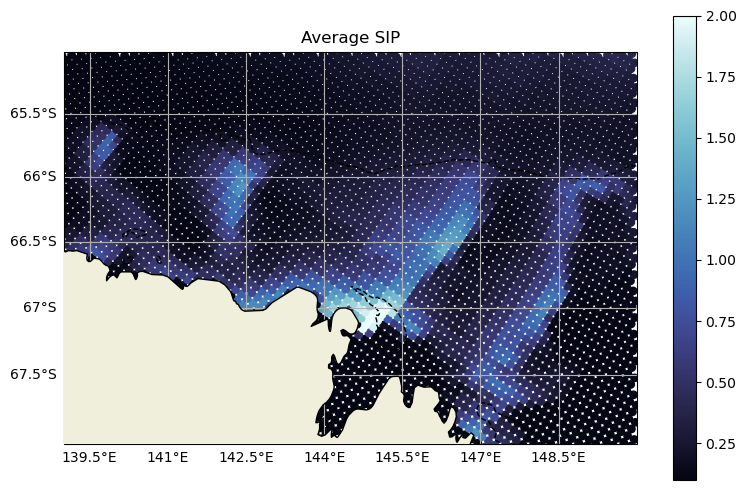

In [15]:

fig, ax = plt.subplots(1,1,figsize=(8,5),subplot_kw={'projection':ccrs.Mercator()})


plot(ax,sip.mean('time'),'Average SIP')
plt.tight_layout()

In [17]:
gi = xr.open_dataarray('gyre_index.nc')


In [19]:
sip.to_netcdf('sip.nc')

In [18]:
gii = gi.interp({'time':sip.time})
cmp = Composite(gii.rolling({'time':12},center=True).mean(),'Gyre Index',frac=0.2)

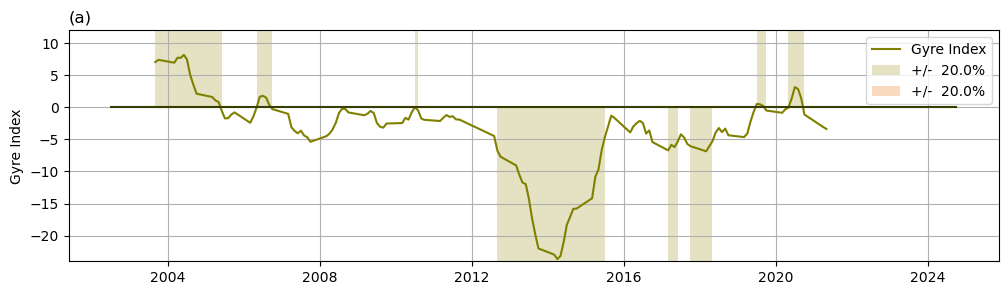

In [19]:
fig,ax = plt.subplots(1,1,figsize=(12,3))
cmp.composite_timeseries(ax,ylim=[-24,12])


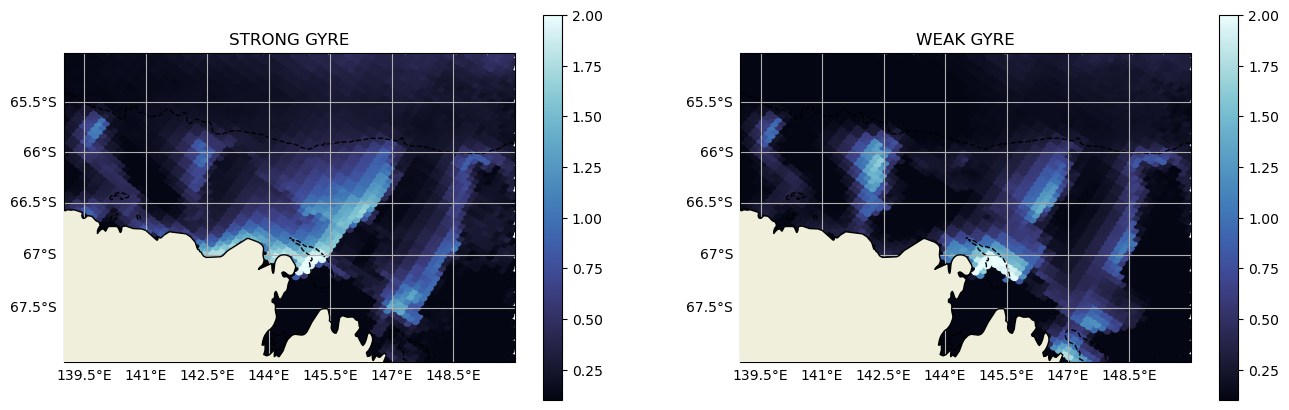

In [20]:
# extract data where positive and negative
sip_pos = sip.where(cmp.idx_positive_with_lag,drop=True).mean('time')
sip_neg = sip.where(cmp.idx_negative_with_lag,drop=True).mean('time')

fig,axs = plt.subplots(1,2,figsize=(16,5),subplot_kw={'projection':ccrs.Mercator()})

# plot pos and neg maps
im1=plot(axs[0],sip_pos,'STRONG GYRE')
im2=plot(axs[1],sip_neg,'WEAK GYRE')


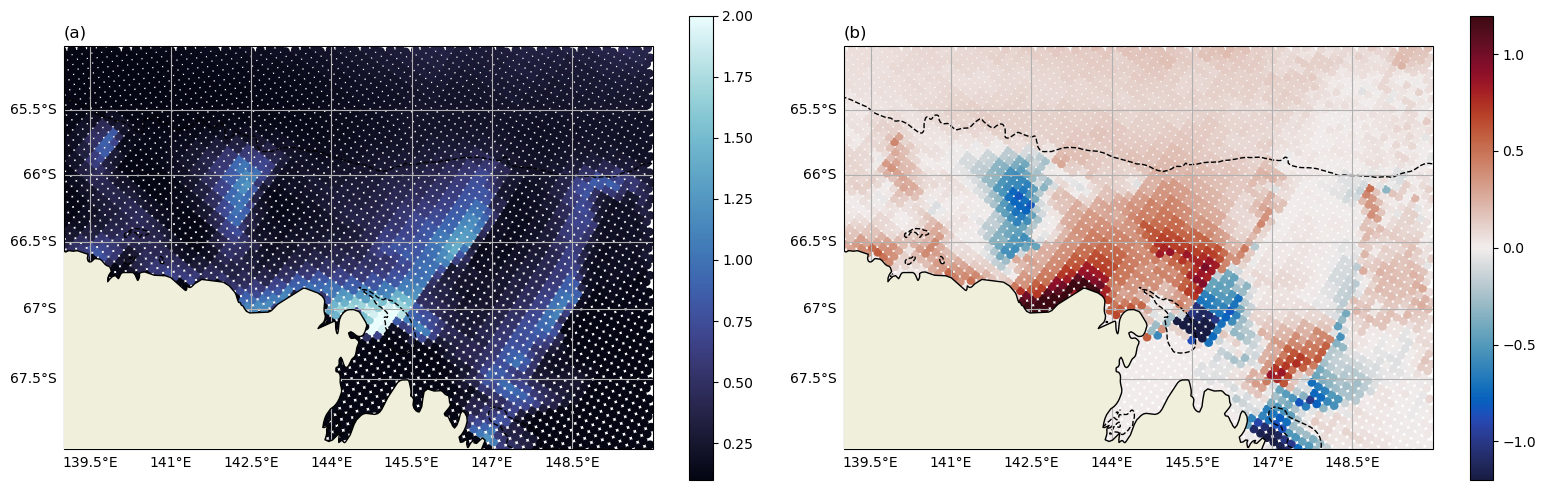

In [24]:
fig,axs = plt.subplots(1,2,figsize=(16,5),subplot_kw={'projection':ccrs.Mercator()})

plot(axs[0],sip.mean('time'),'(a)')
plot(axs[1],sip_pos-sip_neg,'(b)',vmax=1.2,vmin=-1.2,cmap=cmocean.cm.balance)

plt.tight_layout()



In [25]:
sic = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__

In [26]:
sic['month'] = sic.time.dt.month
sic_filtered = sic.interp({'time':sip.time})#where((sic.month >=3) & (sic.month <=10),drop=True)
sic_filtered = fns.crop_to_extent(sic,extent)

sic_pos = sic_filtered.where(cmp.idx_positive_with_lag,drop=True).mean('time')
sic_neg = sic_filtered.where(cmp.idx_negative_with_lag,drop=True).mean('time')


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'title'
  result = super().contour(*args, **kwargs)


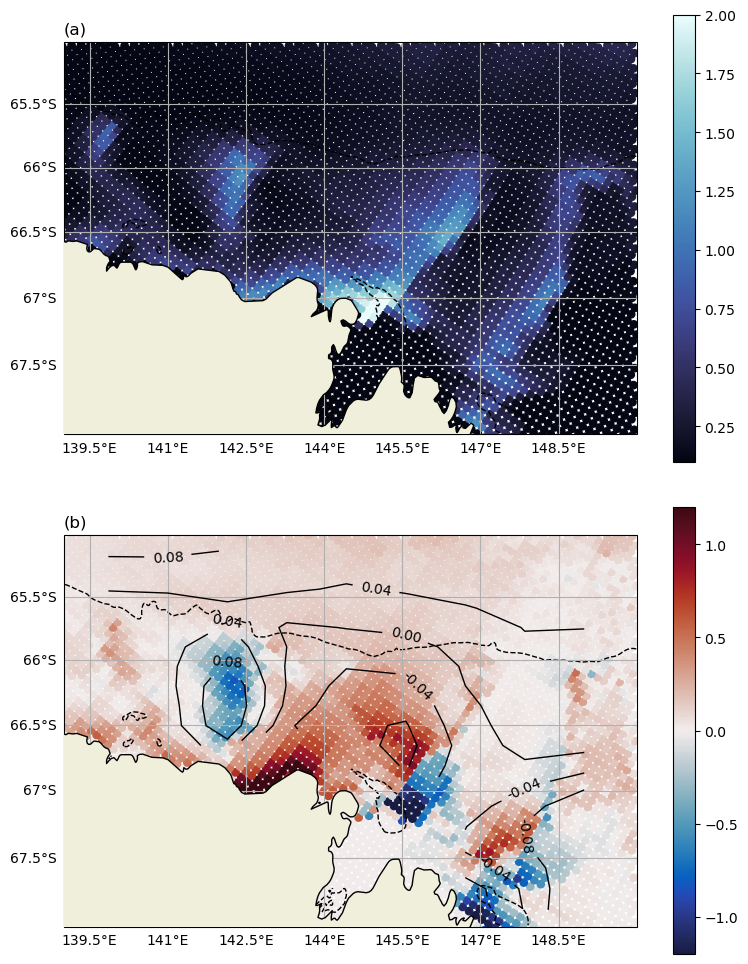

In [32]:
fig,axs = plt.subplots(2,1,figsize=(8,10),subplot_kw={'projection':ccrs.Mercator()})

plot(axs[0],sip.mean('time'),'(a)')
plot(axs[1],sip_pos-sip_neg,'(b)',vmax=1.2,vmin=-1.2,cmap=cmocean.cm.balance)

im=(sic_pos-sic_neg).plot.contour(x='longitude',y='latitude',ax=axs[1],transform=ccrs.PlateCarree(),levels=[-0.08,-0.04,0,0.04,0.08],colors='k',vmin=-0.15,vmax=0.15,linewidths=1,linestyles='-',title=None)
im=axs[1].clabel(im, inline=True, fontsize=10, fmt='%1.2f')
axs[1].set_title(None)#'(b)',loc='left')
plt.tight_layout()


In [47]:
dot_ds = DOT(ver='egm').ds
lwe_ds = GRACE().ds
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,#sla_,#SLA(deg=1).da,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


In [51]:
sha = sha_ds_sla.sha.interp({'time':sip.time})
sha = fns.crop_to_extent(sha,extent)

In [52]:
sha_pos = sha.where(cmp.idx_positive_with_lag,drop=True).mean('time')
sha_neg = sha.where(cmp.idx_negative_with_lag,drop=True).mean('time')

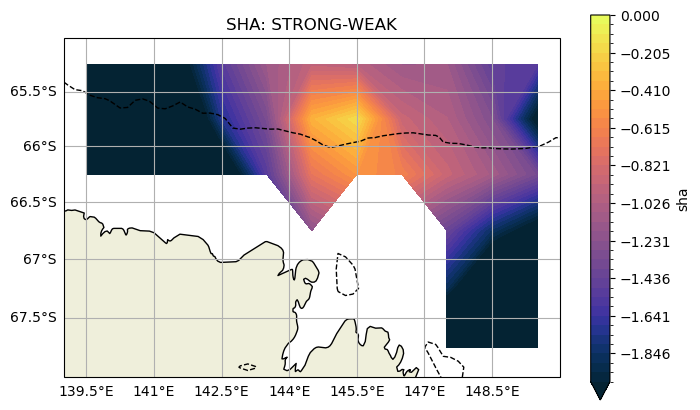

In [ ]:
fig,axs = plt.subplots(1,1,figsize=(8,5),subplot_kw={'projection':ccrs.Mercator()})

fns.plotc(axs,sha_pos-sha_neg,'SHA: STRONG-WEAK',extent,vmin=-2,vmax=0,cmap=cmocean.cm.thermal_r)